<h1>SpaceX  Falcon 9 First Stage Landing Prediction</h1>


<h1>Objectives</h1>
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


In [4]:
#Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


In [3]:
df=pd.read_csv("dataset_part_2.csv")
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


<h2>The Relationship between Flight Number and Payload Mass</h2>

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


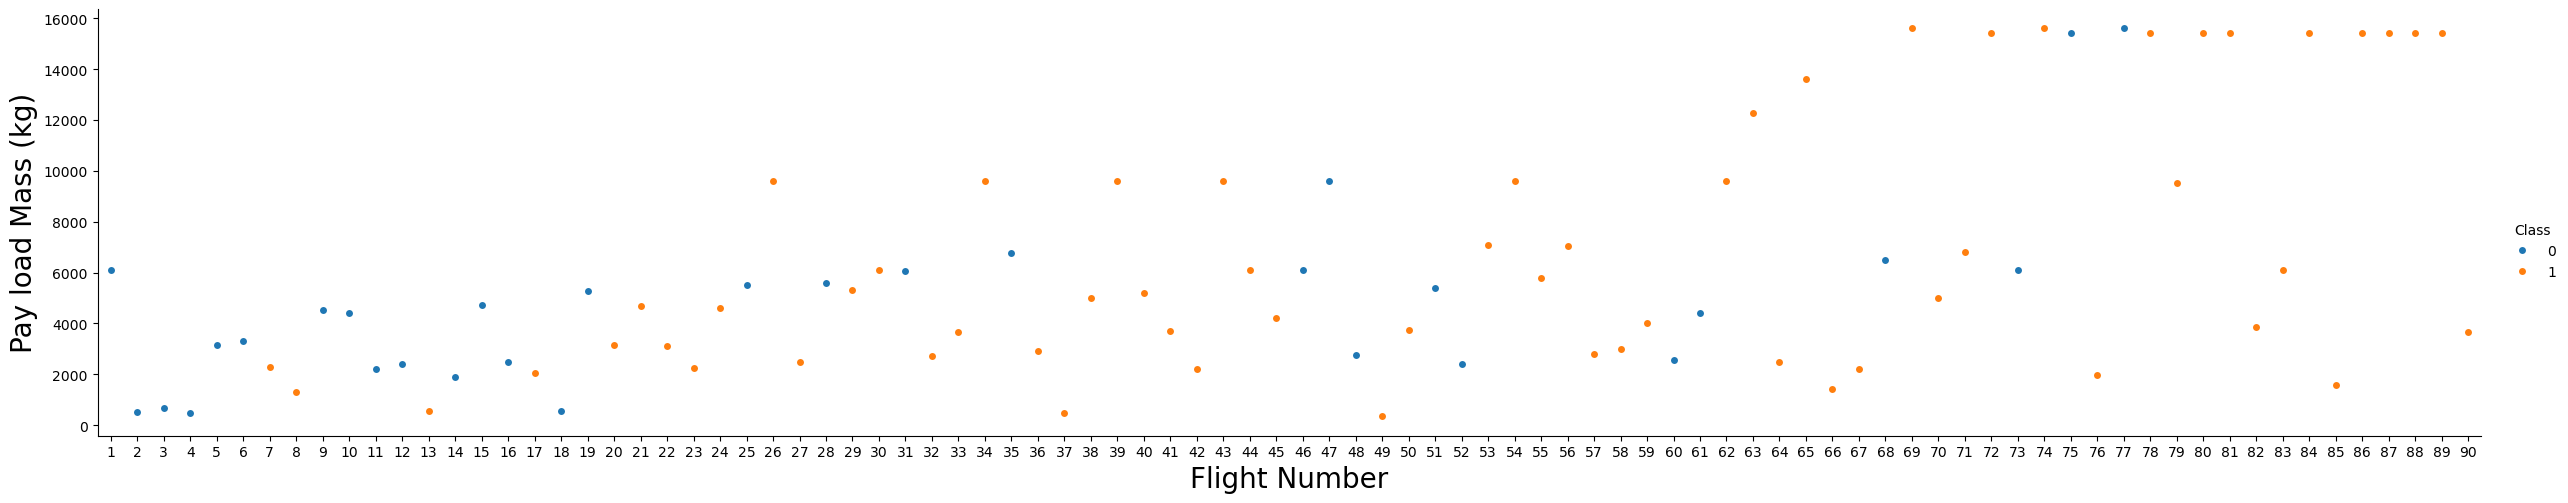

In [5]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show() 

<h2>The relationship between Flight Number and Launch Site</h2>


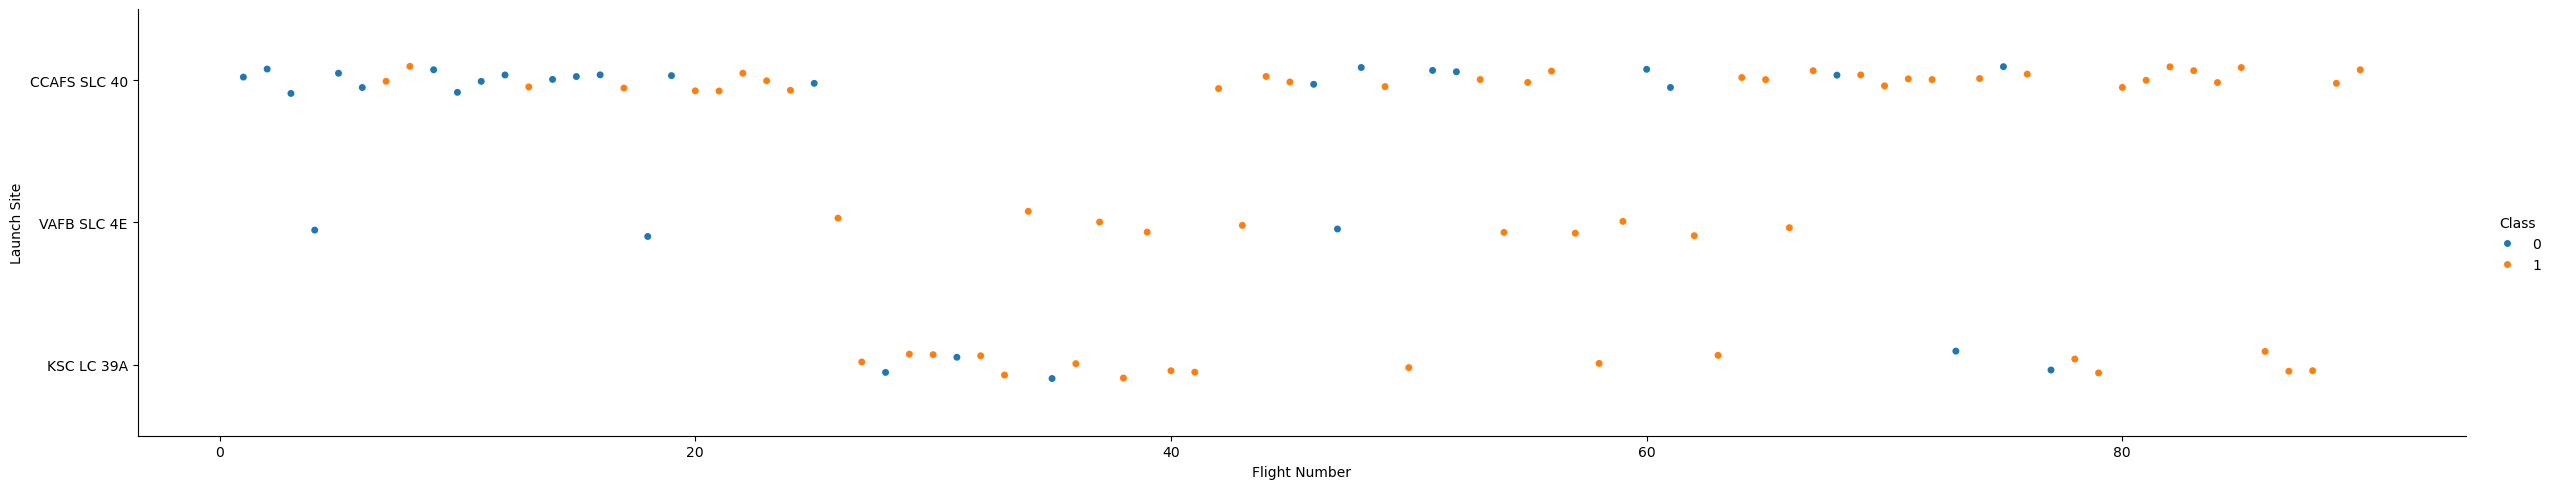

In [6]:
sns.catplot(x="FlightNumber",y="LaunchSite",hue="Class",data=df,aspect=5)
plt.xlabel("Flight Number")
plt.ylabel("Launch Site")
plt.show()

<ul>
<li>Most launches Happen in CCAFS SLC 40</li>
<li>Both successes (1) and failures (0) are present in CCFAS slc 40</li>
<li>KSC LC 39A has fewer launches compared to CCAFS</li>
<li>KSC LC 39A has higher proportion of successes hence More Reliable than other</li>
<li>VAFB SLC 4E has least number of launches. It has mixed outcomes, but slightly fewer successes overall</li>

<li>Early flight numbers have more failures and later flight numbers have more successes</li>

<li>Launch sites does impact success rate</li>
</ul>

<h2>Visualize the relationship between Payload and Launch Site</h2>

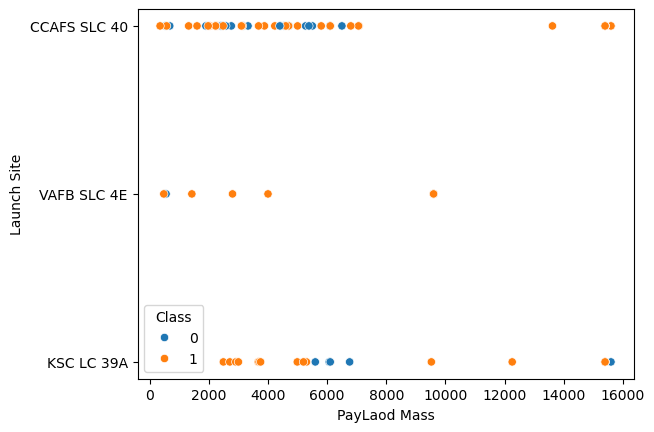

In [8]:
sns.scatterplot(x="PayloadMass",y="LaunchSite",hue="Class",data=df)
plt.xlabel("PayLaod Mass")
plt.ylabel("Launch Site")
plt.show()

In Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


<h2>The relationship between success rate of each orbit type</h2>

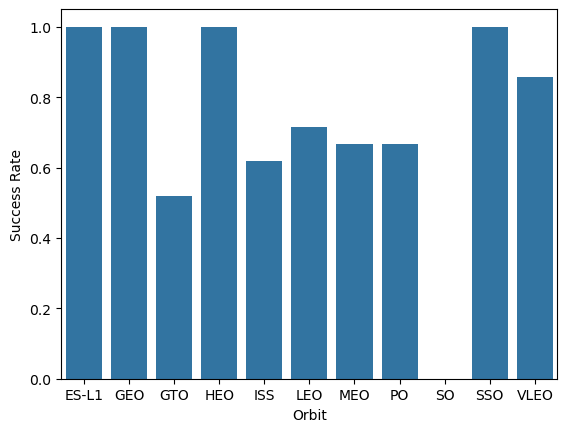

In [9]:
orbit_success=df.groupby("Orbit")["Class"].mean().reset_index()
sns.barplot(x="Orbit",y="Class",data=orbit_success)
plt.xlabel("Orbit")
plt.ylabel("Success Rate")
plt.show()

Orbits like ES-L1, GEO, HEO, and SSO orbits have higher succes rate<br>
THEREFORE Orbit types affects mission success

<h2>The relationship between FlightNumber and Orbit type</h2>

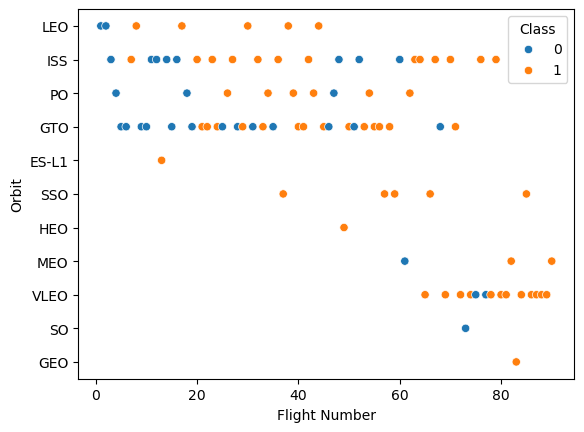

In [10]:
sns.scatterplot(x="FlightNumber",y="Orbit",hue="Class",data=df)
plt.xlabel("Flight Number")
plt.ylabel("Orbit")
plt.show()

Shows how orbit usage and success change over flight numbers.<br>
Certain orbits appear more frequently as flights increase

<h2> The relationship between Payload and Orbit type</h2>

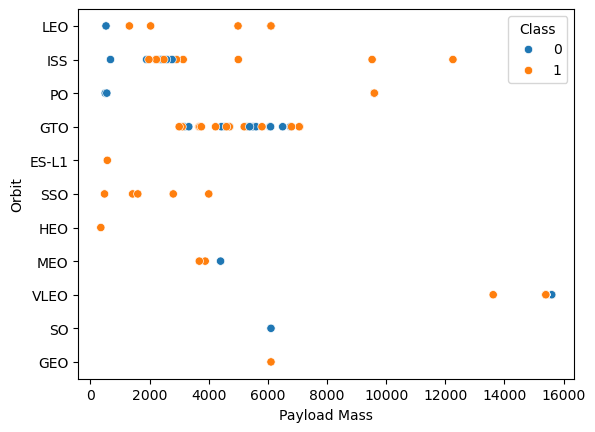

In [11]:
sns.scatterplot(x="PayloadMass",y="Orbit",hue="Class",data=df)
plt.xlabel("Payload Mass")
plt.ylabel("Orbit")
plt.show()

Higher payload has more success<br>
LEO and ISS  are most reliable because it has more successful landings.<br>
GTO has both success and failure across different payload ranges which will make it harder to predict the outcome<br>
Many Failures appear in low payload region<br>


<h2> Visualize the launch success yearly trend</h2>

You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 
"

In [12]:
# A function to Extract years from the date 
year=[]
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
    

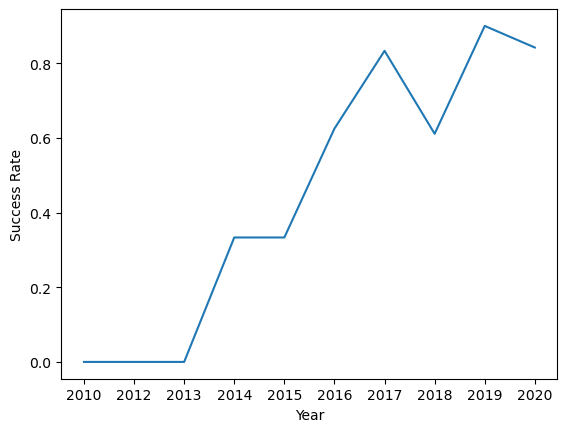

In [ ]:
df["Year"]=df['Date'].apply(lambda x:x.split("-")[0])
yearly_success = df.groupby("Year")["Class"].mean().reset_index()
sns.lineplot(x="Year", y="Class", data=yearly_success)

plt.xlabel("Year")
plt.ylabel("Success Rate")
plt.show()

You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.


In [14]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


<h2>Create dummy variables to categorical columns</h2>

Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.
"

In [ ]:

features_one_hot=pd.get_dummies(features,columns=["Orbit","LaunchSite","LandingPad","Serial"])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
